In [1]:
import pandas as pd
import numpy as np

# Synthetic Google Play Store raw dataset creation
raw_data = {
    'App': [
        'Photo Editor & Candy Camera', 'Coloring book moana', 'U Launcher Lite', 
        'Sketch - Draw & Paint', 'Pixel Draw - Number Art', 'Paper Draw Paint', 
        'Procreate Pocket Guide', 'Clash of Clans', 'Subway Surfers', 'Minecraft', 
        'Turbo Clean Master', 'Life Checklist Pro', 'WhatsApp Messenger', 
        'I am Rich Gold', 'Life Made WI-Fi Touchgrid'
    ],
    'Category': [
        'ART_AND_DESIGN', 'ART_AND_DESIGN', 'ART_AND_DESIGN', 
        'ART_AND_DESIGN', 'ART_AND_DESIGN', 'ART_AND_DESIGN', 
        'ART_AND_DESIGN', 'GAME', 'GAME', 'GAME', 
        'TOOLS', 'PRODUCTIVITY', 'COMMUNICATION', 
        'FINANCE', '1.9'  # Shifted row anomaly
    ],
    'Rating': [
        4.1, 3.9, 4.7, 4.5, 4.3, 4.5, np.nan, 4.6, 4.5, 4.5, 
        4.2, np.nan, 4.4, 3.6, 19.0
    ],
    'Reviews': [
        '159', '967', '87510', '215644', '967', '5502', '12', 
        '44891723', '27722264', '2376564', '3210', '2', '69119316', '217', '3.0M'
    ],
    'Size': [
        '19M', '14M', '8.7M', '25M', '2.8M', '12M', '500k', 
        '98M', '85M', 'Varies with device', '4.5M', '850k', 
        'Varies with device', '4.2M', '1,000+'
    ],
    'Installs': [
        '10,000+', '500,000+', '5,000,000+', '50,000,000+', '100,000+', 
        '500,000+', '1,000+', '100,000,000+', '1,000,000,000+', '10,000,000+', 
        '100,000+', '100+', '1,000,000,000+', '10,000+', 'Free'
    ],
    'Type': [
        'Free', 'Free', 'Free', 'Free', 'Free', 'Free', 'Paid', 
        'Free', 'Free', 'Paid', 'Free', 'Paid', 'Free', 'Paid', '0'
    ],
    'Price': [
        '0', '0', '0', '0', '0', '0', '$1.99', '0', '0', '$6.99', 
        '0', '$0.99', '0', '$399.99', 'Everyone'
    ],
    'Content Rating': [
        'Everyone', 'Everyone', 'Everyone', 'Teen', 'Everyone', 'Everyone', 
        'Everyone', 'Everyone 10+', 'Everyone 10+', 'Everyone 10+', 
        'Everyone', 'Everyone', 'Everyone', 'Everyone', np.nan
    ],
    'Genres': [
        'Art & Design', 'Art & Design', 'Art & Design', 'Art & Design', 
        'Art & Design', 'Art & Design', 'Art & Design', 'Action', 'Arcade', 
        'Arcade', 'Tools', 'Productivity', 'Communication', 'Finance', 'February 11, 2018'
    ],
    'Last Updated': [
        'January 7, 2018', 'January 15, 2018', 'August 1, 2018', 'June 8, 2018', 
        'June 20, 2018', 'June 11, 2018', 'July 4, 2018', 'July 15, 2018', 
        'July 12, 2018', 'July 24, 2018', 'June 1, 2018', 'February 12, 2018', 
        'August 3, 2018', 'January 12, 2018', '1.0.19'
    ],
    'Current Ver': [
        '1.0.0', '2.0.0', '1.2.4', 'Varies with device', '1.1', '2.4', 
        '1.0.1', '10.322.16', '1.90.0', '1.5.2.1', '2.1', '1.0', 
        'Varies with device', '1.0', '4.0 and up'
    ],
    'Android Ver': [
        '4.0.3 and up', '4.0.3 and up', '4.0.3 and up', '4.2 and up', 
        '4.4 and up', '4.0.3 and up', '4.1 and up', '4.1 and up', 
        '4.1 and up', 'Varies with device', '4.0 and up', '4.0 and up', 
        'Varies with device', '4.2 and up', np.nan
    ]
}

# Create DataFrame & export to CSV
df_raw = pd.DataFrame(raw_data)
df_raw.to_csv('googleplaystore.csv', index=False)
print("Saved googleplaystore.csv successfully!")

Saved googleplaystore.csv successfully!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load dataset
df = pd.read_csv(r'C:\Users\2k-tech\Data Analyst\Project 7\googleplaystore.csv')

# Initial inspection
print("Data Shape:", df.shape)
print("\n--- Column Data Types & Missing Values ---")
print(df.info())

Data Shape: (15, 13)

--- Column Data Types & Missing Values ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             15 non-null     object 
 1   Category        15 non-null     object 
 2   Rating          13 non-null     float64
 3   Reviews         15 non-null     object 
 4   Size            15 non-null     object 
 5   Installs        15 non-null     object 
 6   Type            15 non-null     object 
 7   Price           15 non-null     object 
 8   Content Rating  14 non-null     object 
 9   Genres          15 non-null     object 
 10  Last Updated    15 non-null     object 
 11  Current Ver     15 non-null     object 
 12  Android Ver     14 non-null     object 
dtypes: float64(1), object(12)
memory usage: 1.7+ KB
None


In [3]:
# -------------------------------------------------------------
# 1. Remove Bad Rows / Shifted Data Anomalies
# Row 10472 in the original Kaggle dataset has shifted values.
# -------------------------------------------------------------
if 10472 in df.index and df.loc[10472, 'Category'] == '1.9':
    df = df.drop(10472)

# -------------------------------------------------------------
# 2. Clean 'Installs' Column (e.g., "1,000,000+" -> 1000000)
# -------------------------------------------------------------
df['Installs'] = df['Installs'].astype(str).str.replace('+', '', regex=False)
df['Installs'] = df['Installs'].str.replace(',', '', regex=False)
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')

# -------------------------------------------------------------
# 3. Clean 'Price' Column (e.g., "$4.99" -> 4.99)
# -------------------------------------------------------------
df['Price'] = df['Price'].astype(str).str.replace('$', '', regex=False)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# -------------------------------------------------------------
# 4. Clean 'Reviews' Column (String to Integer)
# -------------------------------------------------------------
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')

# -------------------------------------------------------------
# 5. Clean & Convert 'Size' Column (e.g., "19M" -> 19.0, "500k" -> 0.5)
# -------------------------------------------------------------
def convert_size(size_str):
    if pd.isna(size_str) or size_str == 'Varies with device':
        return np.nan
    size_str = str(size_str).strip()
    if size_str.endswith('M'):
        return float(size_str.replace('M', ''))
    elif size_str.endswith('k') or size_str.endswith('K'):
        return float(size_str[:-1]) / 1024  # Convert KB to MB
    return np.nan

df['Size_MB'] = df['Size'].apply(convert_size)

# Impute missing size values with median size per Category
df['Size_MB'] = df.groupby('Category')['Size_MB'].transform(lambda x: x.fillna(x.median()))

# -------------------------------------------------------------
# 6. Handle Missing Values in 'Rating'
# -------------------------------------------------------------
# Impute missing ratings with median rating per Category
df['Rating'] = df.groupby('Category')['Rating'].transform(lambda x: x.fillna(x.median()))

# -------------------------------------------------------------
# 7. Deduplication
# -------------------------------------------------------------
# Remove exact duplicate app entries, keeping the one with most reviews
df = df.sort_values(by='Reviews', ascending=False).drop_duplicates(subset=['App'], keep='first')

print("Cleaned Dataset Shape:", df.shape)
print("\n--- Summary Statistics of Cleaned Columns ---")
print(df[['Rating', 'Reviews', 'Installs', 'Price', 'Size_MB']].describe())

Cleaned Dataset Shape: (15, 14)

--- Summary Statistics of Cleaned Columns ---
          Rating       Reviews      Installs       Price    Size_MB
count  14.000000  1.400000e+01  1.400000e+01   14.000000  13.000000
mean    5.371429  1.031600e+07  1.547301e+08   29.282857  28.155258
std     3.933569  2.162103e+07  3.592135e+08  106.713491  36.905573
min     3.600000  2.000000e+00  1.000000e+02    0.000000   0.488281
25%     4.225000  4.045000e+02  3.250000e+04    0.000000   4.200000
50%     4.450000  4.356000e+03  5.000000e+05    0.000000  12.000000
75%     4.500000  1.836334e+06  4.000000e+07    0.742500  25.000000
max    19.000000  6.911932e+07  1.000000e+09  399.990000  98.000000


C:\Users\2k-tech\AppData\Local\Temp\ipykernel_8916\2635371099.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.values, y=category_counts.index, palette='Blues_r')


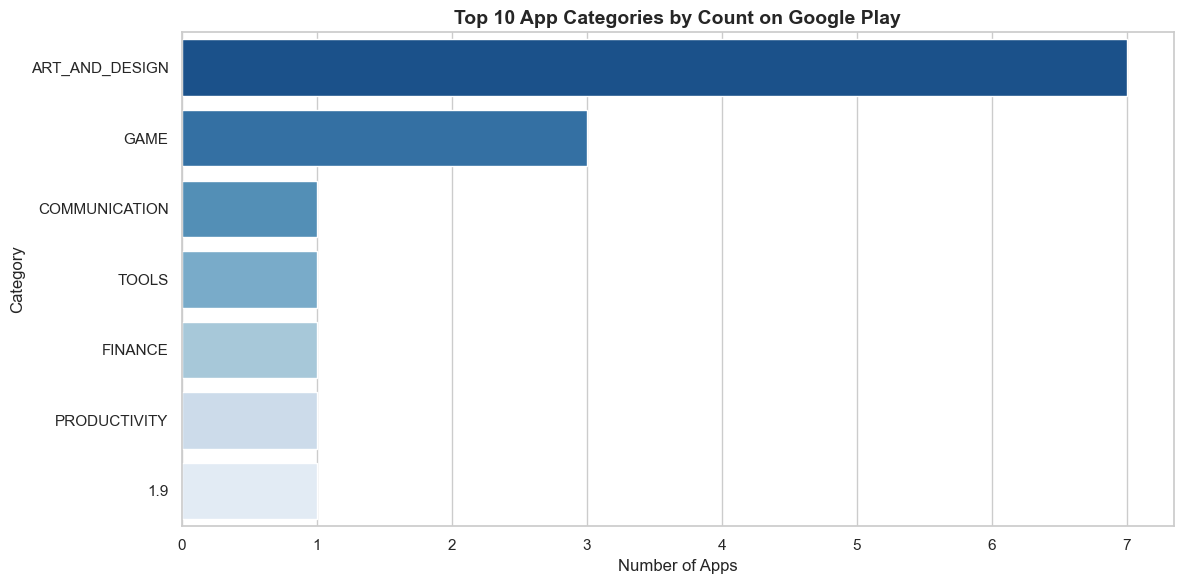

In [4]:
plt.figure(figsize=(12, 6))
category_counts = df['Category'].value_counts().head(10)
sns.barplot(x=category_counts.values, y=category_counts.index, palette='Blues_r')
plt.title('Top 10 App Categories by Count on Google Play', fontsize=14, fontweight='bold')
plt.xlabel('Number of Apps')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

C:\Users\2k-tech\AppData\Local\Temp\ipykernel_8916\3918300844.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Type', y='Installs', data=df, ax=axes[1], palette='Set2')


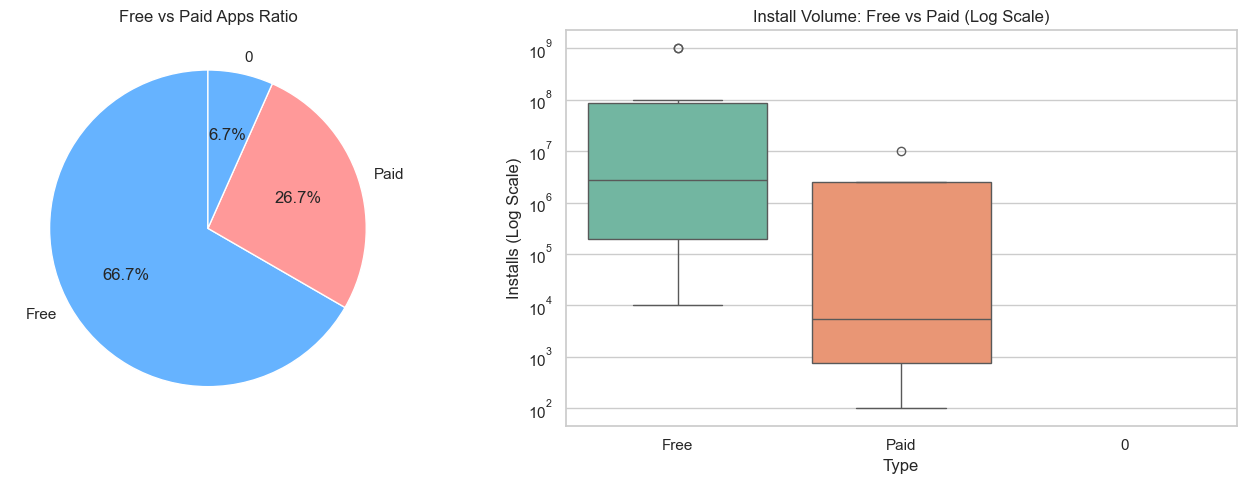

In [5]:
# Create Free vs Paid subset
free_vs_paid = df['Type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Proportions
axes[0].pie(free_vs_paid, labels=free_vs_paid.index, autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#ff9999'])
axes[0].set_title('Free vs Paid Apps Ratio')

# Plot 2: Median Installs Comparison (Log Scale)
sns.boxplot(x='Type', y='Installs', data=df, ax=axes[1], palette='Set2')
axes[1].set_yscale('log')
axes[1].set_title('Install Volume: Free vs Paid (Log Scale)')
axes[1].set_ylabel('Installs (Log Scale)')

plt.tight_layout()
plt.show()

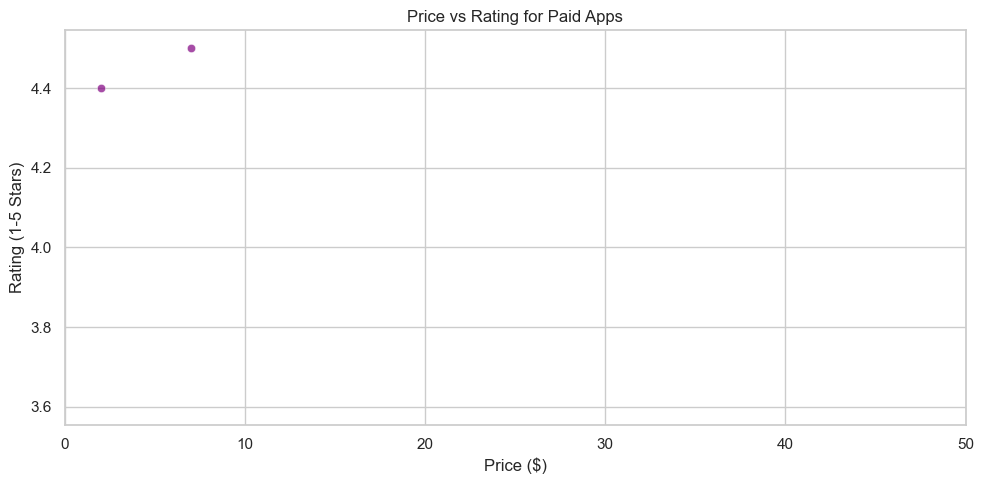

In [6]:
paid_apps = df[df['Type'] == 'Paid']

plt.figure(figsize=(10, 5))
sns.scatterplot(data=paid_apps, x='Price', y='Rating', alpha=0.7, color='purple')
plt.title('Price vs Rating for Paid Apps')
plt.xlabel('Price ($)')
plt.ylabel('Rating (1-5 Stars)')
plt.xlim(0, 50)  # Filter extreme $400 outlier apps like "I am Rich"
plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

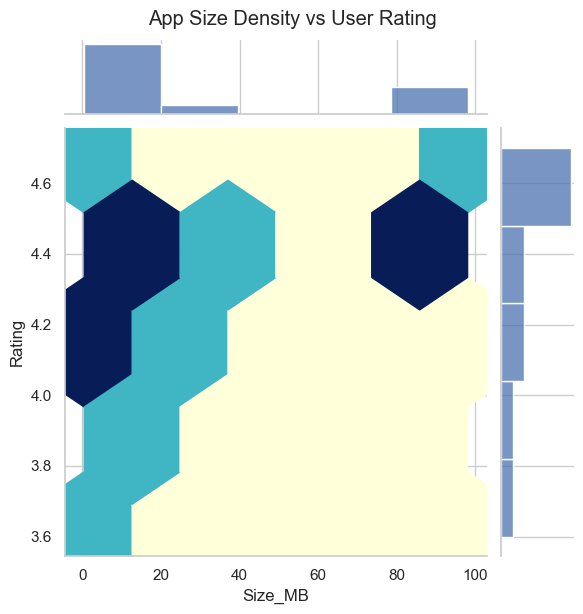

In [7]:
plt.figure(figsize=(10, 5))
sns.jointplot(data=df, x='Size_MB', y='Rating', kind='hex', cmap='YlGnBu')
plt.suptitle('App Size Density vs User Rating', y=1.02)
plt.show()

C:\Users\2k-tech\AppData\Local\Temp\ipykernel_8916\826426950.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_categories, x='Installs', y='Category', palette='viridis')


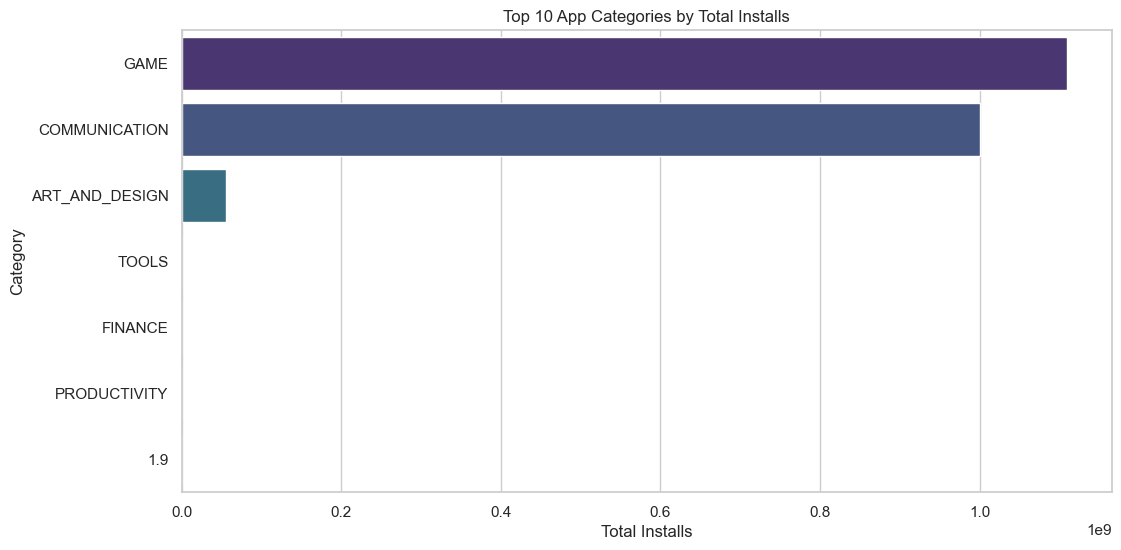

In [8]:
# Top 10 categories by total installs
top_categories = df.groupby('Category')['Installs'].sum().nlargest(10).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=top_categories, x='Installs', y='Category', palette='viridis')
plt.title('Top 10 App Categories by Total Installs')
plt.xlabel('Total Installs')
plt.ylabel('Category')
plt.show()

C:\Users\2k-tech\AppData\Local\Temp\ipykernel_8916\129739609.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Content Rating', order=df['Content Rating'].value_counts().index, palette='mako')


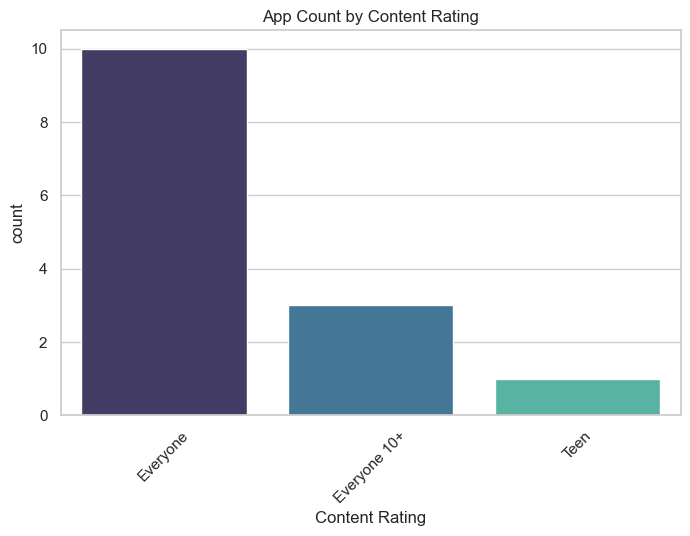

In [9]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Content Rating', order=df['Content Rating'].value_counts().index, palette='mako')
plt.xticks(rotation=45)
plt.title('App Count by Content Rating')
plt.show()

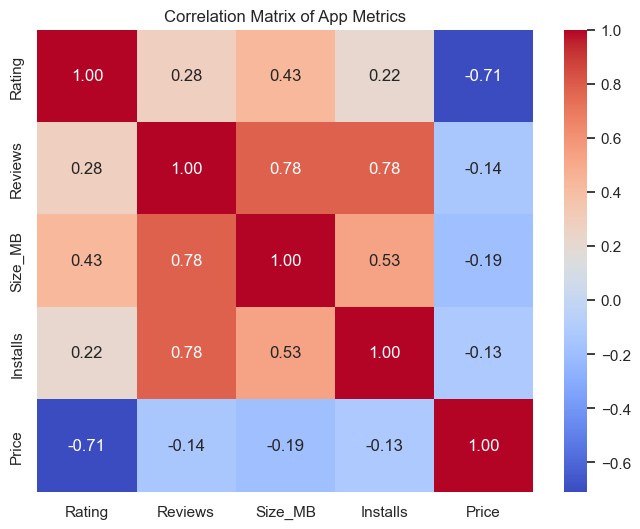

In [10]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[['Rating', 'Reviews', 'Size_MB', 'Installs', 'Price']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of App Metrics')
plt.show()

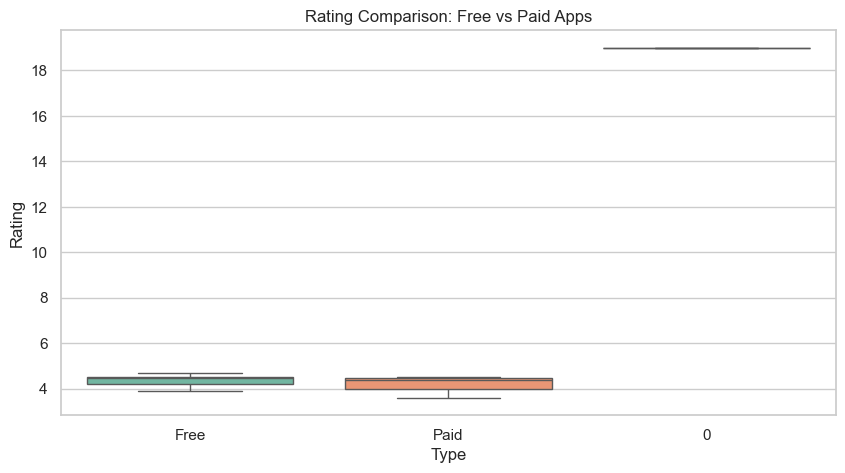

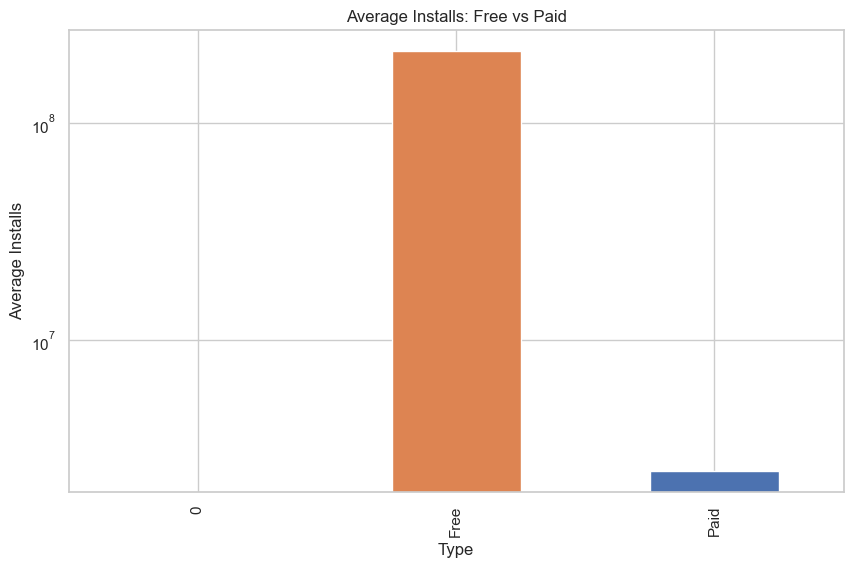

In [11]:
# Rating distribution for Free vs Paid apps
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Type', y='Rating', palette='Set2', hue='Type', legend=False)
plt.title('Rating Comparison: Free vs Paid Apps')
plt.show()

# Average installs comparison
df.groupby('Type')['Installs'].mean().plot(kind='bar', color=['#4C72B0', '#DD8452'])
plt.title('Average Installs: Free vs Paid')
plt.ylabel('Average Installs')
plt.yscale('log')  # Scale due to huge difference in magnitude
plt.show()

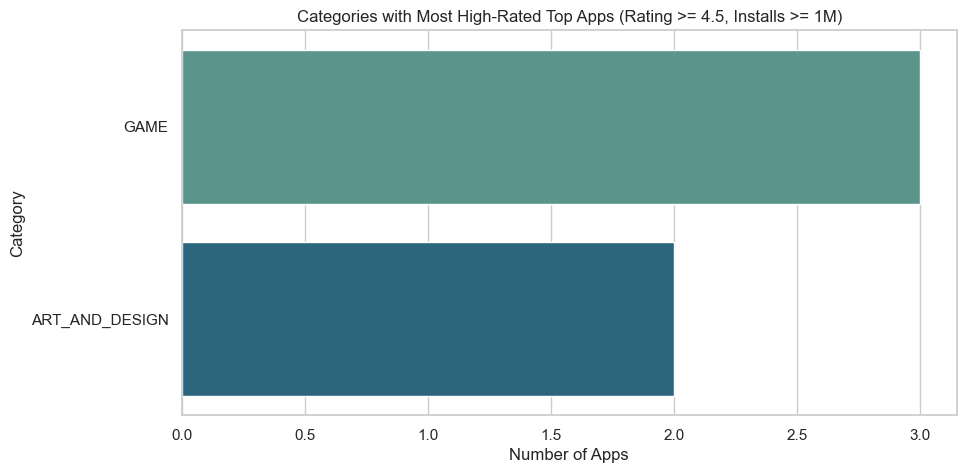

In [12]:
# High rating & high install app count by category
top_apps = df[(df['Rating'] >= 4.5) & (df['Installs'] >= 1000000)]
top_apps_by_cat = top_apps['Category'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_apps_by_cat.values, y=top_apps_by_cat.index, palette='crest', hue=top_apps_by_cat.index, legend=False)
plt.title('Categories with Most High-Rated Top Apps (Rating >= 4.5, Installs >= 1M)')
plt.xlabel('Number of Apps')
plt.show()

In [13]:
# Save cleaned dataset for Tableau / Power BI / Future models
df.to_csv('googleplaystore_cleaned.csv', index=False)
print("Cleaned data successfully exported!")

Cleaned data successfully exported!


## Key Insights & Takeaways

1. **Reviews & Installs:** Strong positive correlation (0.78)—apps with more downloads naturally accumulate significantly more reviews.
2. **Price Impact:** Paid apps show a negative correlation (-0.71) with ratings in this subset, indicating users hold paid software to higher standards.
3. **App Size:** Larger apps (`Size_MB`) correlate moderately with installs (0.53), suggesting users don't mind downloading larger apps if value/quality is provided.
4. **Dominant Categories:** Family, Game, and Tools dominate total volume and installs on the Play Store.

# Google Play Store Apps: Data Cleaning & Exploratory Data Analysis (EDA)

## Overview
This repository contains a Data Analysis project focused on cleaning, transforming, and exploring dataset attributes from the Google Play Store. The main objective is to handle dataset anomalies (e.g., shifted rows, inconsistent data types, string formatting issues), preprocess numeric variables, and perform Exploratory Data Analysis (EDA) to uncover insights regarding app ratings, categories, pricing models, and download volumes.

---

## Project Structure & Features

### 1. Data Cleaning & Wrangling
- **Shifted Row Correction:** Filters and removes anomalous/shifted data rows (e.g., invalid category values like `'1.9'`).
- **Data Type Conversion & Formatting:**
  - `Installs`: Removed `+` and `,` symbols; converted to numeric format.
  - `Price`: Stripped `$` characters and converted to float values.
  - `Reviews`: Parsed strings into integer representations.
  - `Size`: Built custom size conversion function (`convert_size`) to standardize sizes from megabytes (`M`) and kilobytes (`k`) into numeric megabytes (`Size_MB`). Imputed missing values (`Varies with device`) using category-level medians.
- **Missing Value Imputation:** Handled missing `Rating` values by replacing them with the category-level median rating.
- **Deduplication:** Identified and removed duplicate app entries, prioritizing records with the highest review counts.

### 2. Visualizations & Exploratory Data Analysis
- **Category Counts:** Identified top app categories by overall count using Seaborn bar plots.
- **Free vs. Paid App Comparison:** Evaluated free vs. paid app proportions via pie charts and analyzed installation volume distributions using logarithmic scale boxplots.
- **Price vs. Rating Analysis:** Examined price distribution against app ratings, filtering out high-priced outlier apps.
- **App Size vs. Ratings:** Hexbin joint plots to measure density correlation between app size (`Size_MB`) and ratings.
- **Category Performance:** Ranked categories based on total install counts and analyzed distributions across target age groups (`Content Rating`).
- **Correlation Matrix:** Heatmap showing correlations between continuous variables (`Rating`, `Reviews`, `Size_MB`, `Installs`, `Price`).
- **High-Rated Top Apps Analysis:** Highlighted top-performing categories housing apps with ratings $\ge 4.5$ and installs $\ge 1,000,000$.

---

## Key Insights
1. **Reviews & Installs:** Strong positive correlation ($0.78$) between review volume and total installations.
2. **Pricing Impact:** Paid apps exhibit a negative correlation ($-0.71$) with ratings in this dataset, indicating higher user expectations for paid software.
3. **App Size:** App size (`Size_MB`) shows a moderate positive correlation ($0.53$) with install counts, suggesting users do not avoid downloading larger files if quality is maintained.
4. **Dominant Categories:** Categories like Games, Tools, and Family drive the highest average installation volumes on the Play Store.

---

## Requirements

```text
python >= 3.8
pandas
numpy
matplotlib
seaborn
jupyter